In [38]:
import pandas as pd
import numpy as np
import os
import re

def map_geneID(gene_list):
    gff_file = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()),'metadata','gffFile_combined.gff'), sep='\t', comment='#', header=None)
    gene_ID={}
    for i in range(len(gff_file)):
        if gff_file.iloc[i,2]=='gene':
            attributes=gff_file.iloc[i,8]
            # 1. Extract the primary official name
            # 1. Extract 'gene'
            # Looks for 'gene=' and captures any character that is NOT a semicolon [^;]+
            gene_match = re.search(r'Name=([^;]+)', attributes)
            gene = gene_match.group(1) if gene_match else None

            # 2. Extract 'locus_tag'
            # Looks for 'locus_tag=' and captures any character that is NOT a semicolon [^;]+
            locus_match = re.search(r'locus_tag=([^;]+)', attributes)
            locus_tag = locus_match.group(1) if locus_match else None
            gene_ID[locus_tag]=gene
    mapped_genes = []
    for gene in gene_list:
        try:
            mapped_genes.append(gene_ID[gene])
        except KeyError:
            mapped_genes.append(gene)
    return mapped_genes


def get_gene_synonyms():
    gtf_file = pd.read_csv(os.path.join(os.path.dirname(os.getcwd()),'metadata','genomic.gtf'), sep='\t', comment='#', header=None)
    gene_synonyms={}
    for i in range(len(gtf_file)):
        if gtf_file.iloc[i,2]=='gene':
            attributes=gtf_file.iloc[i,8]
            # 1. Extract the primary official name
            gene_match = re.search(r'gene "([^"]+)"', attributes)

            if gene_match:
                primary_gene = gene_match.group(1)   # This is "thrA"

                # 2. Extract ALL synonyms as a temporary list
                # findall returns: ['ECK0002', 'Hs', 'thrA1', 'thrA2']
                synonym_list = re.findall(r'gene_synonym "([^"]+)"', attributes)

                # 3. Loop through the list and map EACH one individually to the primary name
                for syn in synonym_list:
                    gene_synonyms[syn] = primary_gene  # e.g., gene_synonyms["Hs"] = "thrA"
    return gene_synonyms


def standardize_gene(gene_name, mapping_dict):
    # .get() looks for the synonym; if it doesn't find it, it returns the original name
    return mapping_dict.get(gene_name, gene_name)


def map_gene_names(bulk_genes, sc_genes):
    # Convert arr2 to a set for O(1) lookups
    # Find genes unique to each dataset
    only_in_bulk = list(set(bulk_genes) - set(sc_genes))
    only_in_sc = list(set(sc_genes) - set(bulk_genes))
    print(f"Unmatched bulk genes before mapping: {len(only_in_bulk)}")
    print(f"Unmatched single-cell genes before mapping: {len(only_in_sc)}")
    bulk_genes = map_geneID(bulk_genes)
    sc_genes = [s.replace('LELOBEKK_','') for s in sc_genes]
    # get gene synonyms dict
    gene_synonyms = get_gene_synonyms()
    # 1. Convert every gene in both lists to its official canonical name
    standardized_bulk = [standardize_gene(g, gene_synonyms) for g in bulk_genes]
    standardized_sc = [standardize_gene(g, gene_synonyms) for g in sc_genes]
    only_in_bulk = list(set(standardized_bulk) - set(standardized_sc))
    only_in_sc = list(set(standardized_sc) - set(standardized_bulk))
    print(f"Unmatched bulk genes after mapping: {len(only_in_bulk)}")
    print(f"Unmatched single-cell genes after mapping: {len(only_in_sc)}")
    return standardized_bulk, standardized_sc


bulk_data = pd.read_excel(r'C:\Users\owner\Documents\Projects\dysregulated-persistence\bulk_data\All bulk data.xlsx', index_col=0)
#bulk_data = pd.read_csv(r"C:\Users\owner\Documents\Projects\dysregulated-persistence\bulk_data\exp0224_count_data.csv", index_col=0)
bulk_data = bulk_data.iloc[:, 11:16]
sc_data = pd.read_csv(r"C:\Users\owner\Documents\Projects\dysregulated-persistence\data_for_paper\SHX_biorep6A.csv", index_col=0)
bulk_genes = bulk_data.index.tolist()
sc_genes = sc_data.columns.tolist()

bulk_mapped, sc_mapped = map_gene_names(bulk_genes, sc_genes)
# Convert both to lowercase sets
set1 = {s.lower() for s in bulk_mapped}
set2 = {s.lower() for s in sc_mapped}

# Find the intersection
intersection = list(set1 & set2)
common_genes = np.unique(intersection)
correlation_data = pd.DataFrame(index=common_genes)
aggregated_sc = pd.DataFrame(index=sc_genes)
aggregated_sc['mapped_genes'] = [s.lower() for s in sc_mapped]
aggregated_sc['counts'] = np.mean(sc_data,axis=0).tolist()
bulk_avg = pd.DataFrame(index=bulk_genes)
bulk_avg['mapped_genes'] = [s.lower() for s in bulk_mapped]
bulk_avg['counts'] = np.mean(bulk_data.iloc[:,1:6],axis=1).tolist()
correlation_data['bulk']=np.zeros(len(common_genes))
correlation_data['single-cell']=np.zeros(len(common_genes))
for i in range(len(aggregated_sc)):
    if aggregated_sc['mapped_genes'][i] in correlation_data.index:
        correlation_data.loc[aggregated_sc['mapped_genes'][i],'single-cell'] += aggregated_sc.iloc[i,1]
        correlation_data.loc[aggregated_sc['mapped_genes'][i],'index'] = i
for i in range(len(bulk_avg)):
    if bulk_avg['mapped_genes'][i] in correlation_data.index:
        correlation_data.loc[bulk_avg['mapped_genes'][i],'bulk'] += bulk_avg.iloc[i,1]

Unmatched bulk genes before mapping: 2726
Unmatched single-cell genes before mapping: 402
Unmatched bulk genes after mapping: 2371
Unmatched single-cell genes after mapping: 126


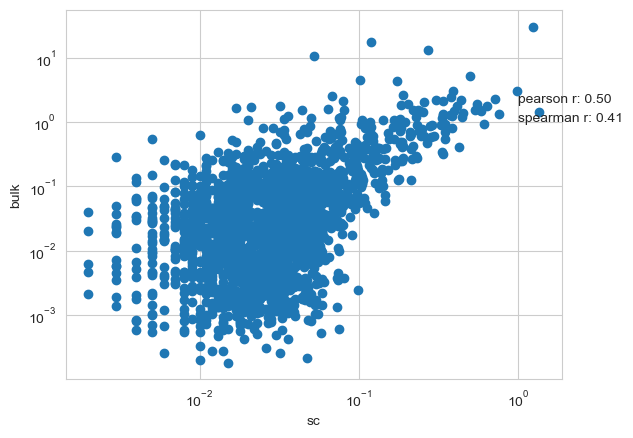

PearsonRResult(statistic=0.5002770175525547, pvalue=1.6785871498184595e-118)
SignificanceResult(statistic=0.4139302777964502, pvalue=5.49474302841229e-78)


In [39]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
x = correlation_data['single-cell']
y = correlation_data['bulk']
#x = x[x>1e-3]
#y = y[x>1e-3]
plt.scatter(x,y)
plt.xscale('log')
plt.yscale('log')
r,p = pearsonr(x,y)
s, p_s = spearmanr(x,y)
plt.text(1,2,f'pearson r: {r:.2f}')
plt.text(1,1,f'spearman r: {s:.2f}')
plt.xlabel('sc')
plt.ylabel('bulk')
plt.show()
print(pearsonr(x,y))
print(spearmanr(x,y))

(495, 990)
corr index: 16.016022916500454
lambda max: 16.05952322423836
fraction: 0.08315069890827466


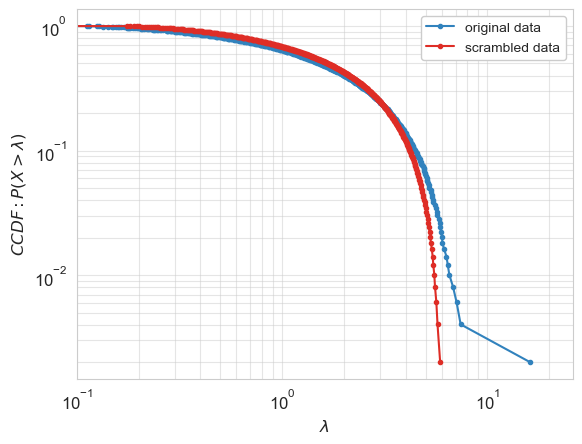

In [188]:
import src.data_functions as data_func
import src.analysis_functions as af
fsize = 12
def get_data_for_plot(data, norm=True, log=False, norm_method='sum', norm_sum=1):
    m = data.to_numpy()
    pcs, pcs1, fraction_non_zeros = af.get_eig_dist(m, norm=norm, log=log, norm_method=norm_method, norm_sum=norm_sum)
    return pcs, pcs1, m.shape[0], fraction_non_zeros

def plot_eigvals(ax, pcs, pcs1, N, x_max, y_max, n_bins, x_label=True, y_label=True):
    # plot the eigenvalue distribution of the normalized filtered matrix
    # define limits and bin number
    P = len(pcs)
    scale = 1  # scale factor for the Marchenko-Pastur distribution
    edges = np.linspace(-0.1, x_max, num=n_bins)

    # remove zeros in pcs and pcs1
    # if alpha>1 adjust the scale factor to match theoretical results
    if P / N > 1:
        scale = N / P
        pcs = pcs[pcs != 0]
        pcs1 = pcs1[pcs1 != 0]

    # first plot
    counts, bins = np.histogram(pcs, bins=edges, density=True)
    ax.plot(bins[1:], scale * counts, color='#3182bd', linewidth=1, label='original data')
    ax.fill_between(bins[1:], scale * counts, 0, color='#9ecae1', alpha=.4)
    # second plot
    counts, bins = np.histogram(pcs1, bins=edges, density=True)
    ax.plot(bins[1:], scale * counts, color='#de2d26', linewidth=1, label='scrambled data')
    ax.fill_between(bins[1:], scale * counts, 0, color='#fc9272', alpha=.4)
    # plot analytical Marchenko-Pastur distribution
    x = np.linspace(-0.1, x_max, 100)
    y = [af.mp_distribution(val, P / N) for val in x]
    ax.plot(x, y, color='#756bb1', linestyle='dashed', label='MP')
    # labels and limits
    if x_label:
        ax.set_xlabel("$\lambda$", fontsize=fsize)
    if y_label:
        ax.set_ylabel(r"$\rho(\lambda)$", fontsize=fsize)
    ax.set_ylim(0, y_max)
    ax.set_xlim(0, x_max)
    # set x_ticks with difference of 2
    ax.set_xticks(np.arange(0, (x_max // 2) * 2 + 2, 2))
    # set y_ticks with difference of 0.1
    ax.set_yticks(np.arange(0, (y_max // 0.1) * 0.1 + 0.1, 0.1))
    ax.legend(facecolor='white', framealpha=1, fontsize=fsize-2, loc='upper right')
    # set the font size of the ticks
    ax.tick_params(axis='both', which='major', labelsize=fsize)

def plot_eigvals_ccdf(ax, pcs, pcs1, N, x_label=True, y_label=True):
        # plot the eigenvalue distribution of the normalized filtered matrix
    # define limits and bin number
    pcs = pcs[pcs > 0]
    pcs1 = pcs1[pcs1 > 0]
    p = len(pcs)
    if p != len(pcs1):
        print('pcs1 must have same length as pcs')
    # 1. Sort the data in ascending order
    pcs = np.sort(pcs)
    pcs1 = np.sort(pcs1)

    # 2. Calculate the CDF values (from 1/N to 1)
    # n is the number of data points
    cdf = np.arange(1, p + 1) / p
    # 3. Calculate the CCDF (1 - CDF)
    ccdf = 1 - cdf + (1/p)

    # 4. Plotting
    ax.loglog(pcs, ccdf, marker='.', linestyle='-',color='#3182bd', label='original data')
    ax.loglog(pcs1, ccdf, marker='.',linestyle='-', color='#de2d26', label='scrambled data')
    ax.grid(True, which="both", ls="-", alpha=0.5)

    ax.set_xlim(1e-1, np.max(pcs)+10)
    # labels and limits
    if x_label:
        ax.set_xlabel("$\lambda$", fontsize=fsize)
    if y_label:
        ax.set_ylabel(r"$CCDF: P(X>\lambda)$", fontsize=fsize)

    ax.legend(facecolor='white', framealpha=1, fontsize=fsize-2, loc='upper right')
    # set the font size of the ticks
    ax.tick_params(axis='both', which='major', labelsize=fsize)

correlation_data_filtered = correlation_data[correlation_data['bulk']>1e-3]
index = correlation_data_filtered['index'].astype(int)
P = len(index)
N = int(P/2)
#cell_index = np.random.choice(sc_data.shape[0], size=N, replace=False)
filtered_data = sc_data.iloc[:,index]
cell_index = np.argsort(filtered_data.sum(axis=1))[::-1]
cell_index = cell_index[:N]
filtered_data = filtered_data.iloc[cell_index]
pcs,pcs1,N,fraction = get_data_for_plot(filtered_data)
fig, ax = plt.subplots()
plot_eigvals_ccdf(ax, pcs, pcs1, N)
cor_index = np.sum(pcs[pcs>np.max(pcs1)]-np.max(pcs1))
print(f'corr index: {cor_index}')
print(f'lambda max: {np.max(pcs)}')
print(f'fraction: {fraction}')